In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Data Loading 

In [2]:
trades_data = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv") 

In [3]:
print(sentiment.info())
print(sentiment.shape)

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 127.5 KB
None
(2644, 4)


### Distribution of sentiments

In [4]:
print(sentiment["classification"].value_counts())

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


### Average sentiment value

In [5]:
print(sentiment['value'].mean())

46.981089258698944


## market Sentiment over time

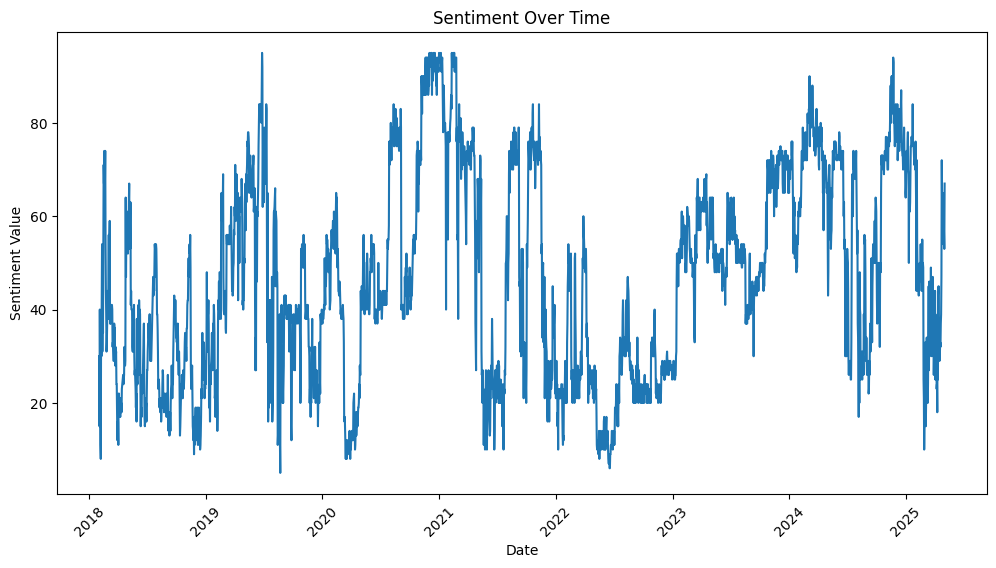

In [16]:
plt.figure(figsize=(12,6))

plt.plot(sentiment['date'], sentiment['value'])

plt.title("Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Sentiment Value")
plt.xticks(rotation=45)

plt.show()

In [7]:
drop_cols = [
    "Account", "Timestamp IST",
    "Transaction Hash", "Order ID",
    "Trade ID", "Start Position", 
]
cleaned_trades_data = trades_data.drop(columns = drop_cols)

In [8]:
print(trades_data.info())
print(trades_data.shape)

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [9]:
trades_data["Closed PnL"].describe()

count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: Closed PnL, dtype: float64

## convert Timsestamp => pandas 

In [10]:
sentiment["date"] = pd.to_datetime(
    sentiment["timestamp"],
    unit = 's'
).dt.date

cleaned_trades_data["date"] = pd.to_datetime(
    cleaned_trades_data["Timestamp"],
    unit = 'ms'
).dt.date

cleaned_trades_data = cleaned_trades_data.drop(columns=['Timestamp'])
sentiment = sentiment.drop(columns=['timestamp'])

## merged both data

In [11]:
merged_df = pd.merge(
    cleaned_trades_data,
    sentiment,
    on='date',
    how='left'
)

In [12]:
# Trader records after May 2, 2025 were removed because corresponding sentiment data was unavailable

print(f" min : {cleaned_trades_data['date'].min() } , max: {cleaned_trades_data['date'].max()}")
print(f" min: {sentiment['date'].min()} , max: {sentiment['date'].max()}")

merged_df = merged_df.dropna(
    subset=['classification', 'value']
)

 min : 2023-03-28 , max: 2025-06-15
 min: 2018-02-01 , max: 2025-05-02


In [13]:
merged_df.groupby('classification')['Closed PnL'].mean()

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64

In [14]:
merged_df.groupby('classification')['Size USD'].mean()

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64

### Correlation Heatmap

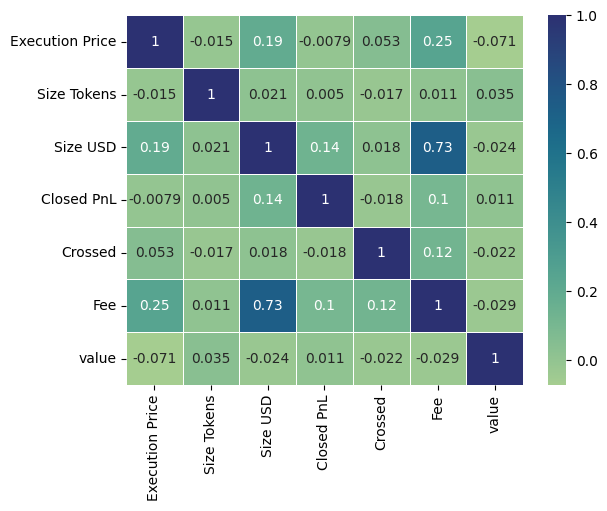

In [17]:
sns.heatmap(
    merged_df.corr(numeric_only=True),
    annot=True,
    cmap = "crest",
    linewidth = .5
)

plt.show()

## Trained Model 

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

In [29]:
# create target
merged_df['profitable'] = (
    merged_df['Closed PnL'] > 0
).astype(int)

In [30]:
# define X and y
X = merged_df.drop(
    columns=[
        'Closed PnL',
        'profitable',
        'Timestamp',
        'datetime',
        'date'
    ],
    errors='ignore'
)

y = merged_df['profitable']

In [31]:
# convert categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)

In [32]:
# split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# train model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# prediction
y_pred = model.predict(X_test)

In [33]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Print scores
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9656201666078745
Precision: 0.9439735759690888
Recall   : 0.97628101836932
F1 Score : 0.9598555178859985

Confusion Matrix:

[[20439   899]
 [  368 15147]]
